## Libraries

In [2]:
from utils.data_loader import load_cifar10
from utils.plots import plot_sample_images, plot_training_history, CIFAR10_CLASSES
from utils.models import build_mlp

## Loading dataset

In [ ]:
(X_train_mlp_cifar10, y_train_mlp_cifar10), (X_test_mlp_cifar10, y_test_mlp_cifar10) = load_cifar10(flatten=True)
print(f"X_train: {X_train_mlp_cifar10.shape}, y_train: {y_train_mlp_cifar10.shape}")
print(f"X_test: {X_test_mlp_cifar10.shape}, y_test: {y_test_mlp_cifar10.shape}")

126459904/170498071 ━━━━━━━━━━━━━━━━━━━━ 13:33 18us/step

## Show MNIST dataset images 

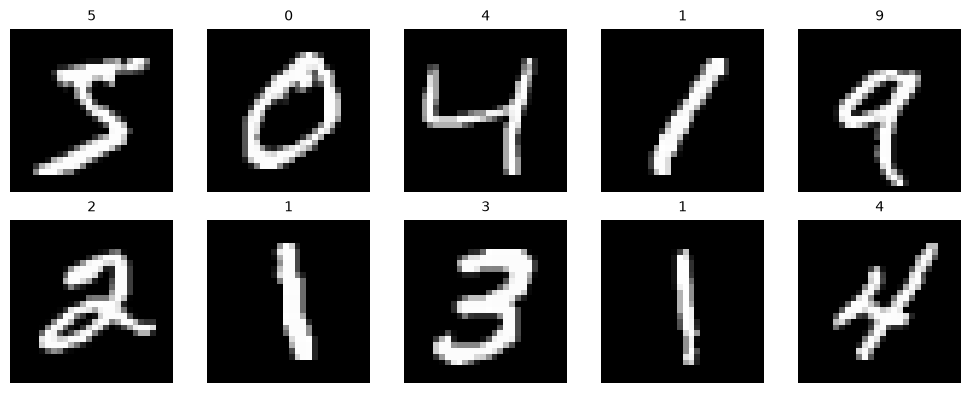

In [ ]:
plot_sample_images(X_train_mlp_cifar10[:10], y_train_mlp_cifar10[:10],CIFAR10_CLASSES)


## Model implementation and training

In [19]:

mlp_model = build_mlp(input_shape=(784,), hidden_units=[128, 64], num_classes=10)
mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Entraînement
history_mlp = mlp_model.fit(
    X_train_mlp_mnist, 
    y_train_mlp_mnist,
    validation_data=(X_test_mlp_mnist, y_test_mlp_mnist),
    epochs=10,
    batch_size=64
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9205 - loss: 0.2711 - val_accuracy: 0.9544 - val_loss: 0.1427
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9665 - loss: 0.1133 - val_accuracy: 0.9675 - val_loss: 0.1044
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9760 - loss: 0.0781 - val_accuracy: 0.9749 - val_loss: 0.0878
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9826 - loss: 0.0563 - val_accuracy: 0.9734 - val_loss: 0.0850
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9854 - loss: 0.0451 - val_accuracy: 0.9764 - val_loss: 0.0790
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9887 - loss: 0.0352 - val_accuracy: 0.9754 - val_loss: 0.0856
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9898 - loss: 0.0306 - val_accuracy: 0.9767 - val_loss: 0.0821
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9916 - loss: 0.0251 - val_accuracy: 0.

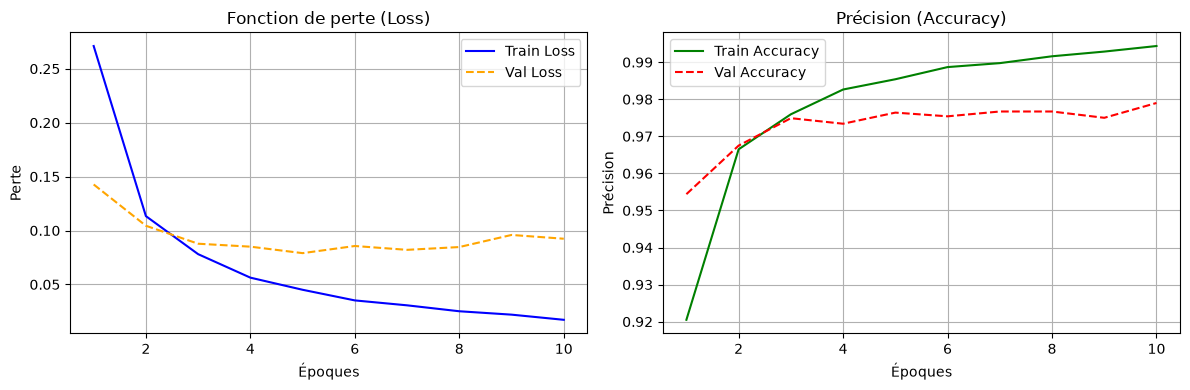

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9790 - loss: 0.0924
Précision sur le jeu de test : 97.90%


In [21]:

# Courbes d'entraînement
plot_training_history(history_mlp)

test_loss, test_acc = mlp_model.evaluate(X_test_mlp_mnist, y_test_mlp_mnist)
print(f"Précision sur le jeu de test : {test_acc * 100:.2f}%")